# 1. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris   # <- troque para outro dataset se quiser (Wine, Breast Cancer etc.)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Carregar o Dataset

In [2]:
dataset = load_iris()   # <- Troque aqui conforme precisar
X, y = dataset.data, dataset.target
feature_names = dataset.feature_names
target_names = dataset.target_names

# 3. Explorar o Dataset

Dimensões do dataset: (150, 5)

Primeiras linhas:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



Resumo estatístico:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



Distribuição das classes:
target
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


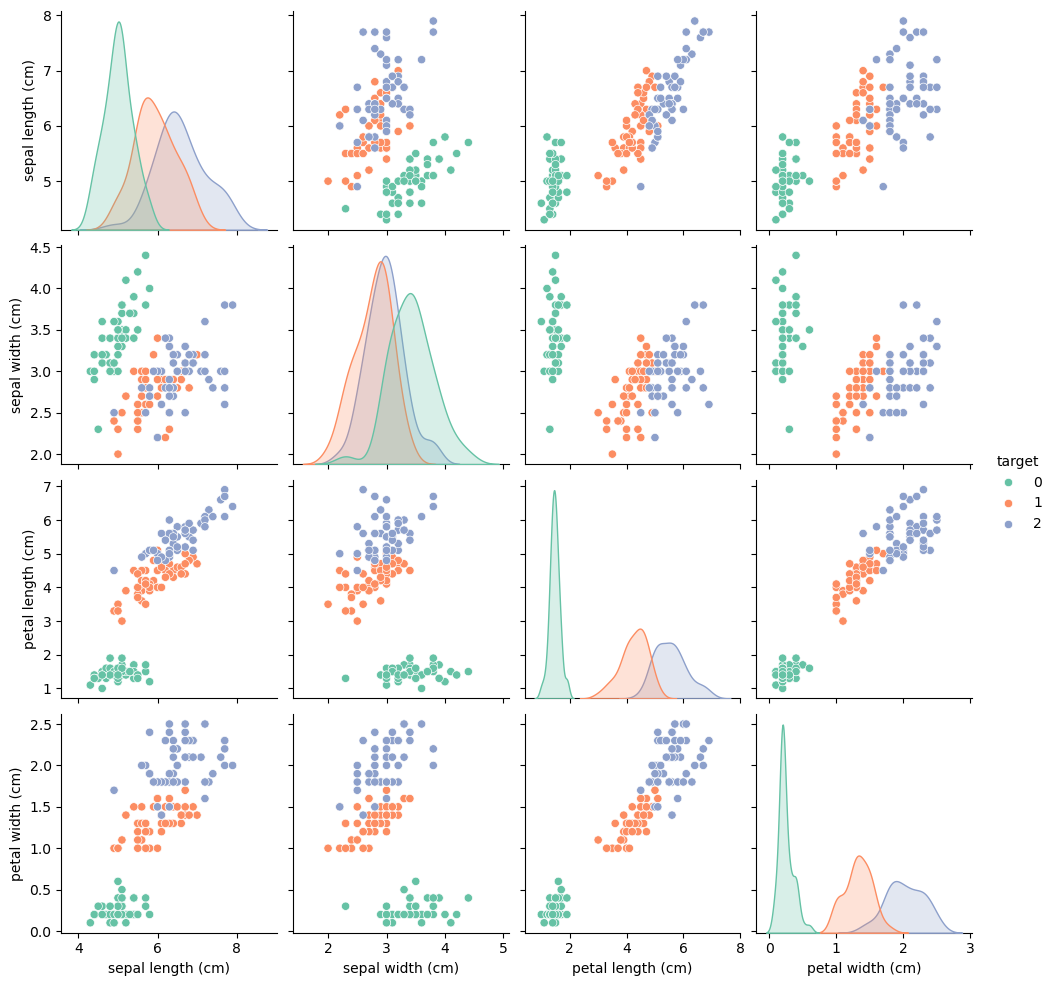

In [3]:
# Converter para DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print("Dimensões do dataset:", df.shape)

print("\nPrimeiras linhas:")
display(df.head())  # display() mostra tabela bonita no Jupyter

print("\nResumo estatístico:")
display(df.describe())

print("\nDistribuição das classes:")
print(df['target'].value_counts().rename(index=dict(enumerate(target_names))))

# Visualização rápida
sns.pairplot(df, hue="target", diag_kind="kde", palette="Set2")
plt.show()

# 4. Pré-Processamento

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Treinamento do Modelo

In [5]:
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# 6. Avaliação

In [6]:
y_pred = model.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred))

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred, target_names=target_names))

Acurácia: 1.0

Matriz de confusão:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Relatório de classificação:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

